# CNN face detector
### **Implemented steps:**

Mounted Google Drive and set up paths to IMG_PATH and OUT_PATH for the output (trained model).
* **Step 0.** Resized images to 128x128 to remain within Drive Storage limit and saved them to *img_labeled_full.csv* with around 5100 faces and 5100 non-faces (clothes, body parts, pets, monkeys, streets, buildings, and landscapes).
* **Step 1.** Data preparation:
  * Split into *img_labeled.csv* with 5000 of each type for training and validation (70-30%) and *img_labeled_test.cvs* with 100 of each type for evaluating the trained model.
  * Set up TensorFlow tf.data.Dataset pipelines including preprocessing and augmentation functions.
* **Step 2.** Model creation:
  * Built and trained a CNN model for face classification from scratch.
  * Evaluated the trained model on a separate test set.
  * Saved the best performing model to Google Drive for re-use.
* **Steps 3 and 4.** Used model to detect faces on pictures:
  * Implemented a sliding window algorithm for face detection on arbitrary images, adjusting window sizes, step size, and confidence threshold.
  * Visualized the results with the bounding boxes.
* **Step 5.** Added Non-Maximum Suppression (NMS) technique to remove overlapping detections for the same face and visualized the final results.

Takeaways and conclusions.

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

img_path = '/content/drive/Othercomputers/Mijn laptop/DS_Advanced/CNN_opdracht/IMG_DATA'
out_path = '/content/drive/Othercomputers/Mijn laptop/DS_Advanced/CNN_opdracht/output'

Mounted at /content/drive


In [2]:
# Optional: double checking that the content is accessible
print(f"Checking contents of: {img_path}")
if os.path.exists(img_path):
    print(os.listdir(img_path))
else:
    print(f"The base image path itself does not exist: {img_path}")

Checking contents of: /content/drive/Othercomputers/Mijn laptop/DS_Advanced/CNN_opdracht/IMG_DATA
['faces', 'no_faces', 'labeled_imgs.csv', 'photos', 'labeled_imgs_test.csv', 'labeled_imgs_full.csv']


# Step 0: Prepare the data
Resize the images on disk, label and save their paths along with the labels into a .csv

(TO EXECUTE ONCE ONLY, unless more physical resizing is needed)

In [ ]:
# ONE TIME operation of in place resizing of all images
import cv2

def resize_images_in_place(directory, im_size):
    """
    Recursively resizes all images in a directory. Overwrites the original files.
    """

    for root, _, files in os.walk(directory):
        for filename in files:
            if not filename.lower().endswith((".jpg", ".jpeg", ".png", ".gif")):
                continue

            file_path = os.path.join(root, filename)
            image = cv2.imread(file_path)

            if image is None:
                print(f"Skipping unreadable file: {file_path}")
                continue

            # Resize to fixed size
            resized = cv2.resize(image, (im_size, im_size), interpolation=cv2.INTER_AREA)

            # Overwrite original file
            if not cv2.imwrite(file_path, resized):
                print(f"Failed to overwrite: {file_path}")

# resize_to = 128
# resize_images_in_place(img_path, resize_to)


In [ ]:
# ANOTHER ONE-TIME operation of labeling and saving photos paths along with their labels in a csv
import pandas as pd

image_filepaths = [] # Changed to store file paths instead of images arrays to avoid memory crash
labels = []

path_f = f"{img_path}/faces"
path_nf = f"{img_path}/no_faces"

label = 1

for p in (path_f, path_nf):
    if p.endswith("no_faces"):
        label = 0
    for f in os.listdir(p):
        # Instead of reading the image, store its full path
        image_filepaths.append(os.path.join(p, f))
        labels.append(label)

# The "photo" column contains file paths, the "face" column contains labels
df = pd.DataFrame({"photo": image_filepaths, "face": labels})
out_csv = os.path.join(img_path, "labeled_imgs_full.csv")
df.to_csv(out_csv)

# Step 1: Data preprocessing
## 1.1 Reading labeled data from .csv, check that images load correctly and split for training

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

In [ ]:
# a cut from labeled_imgs_full.csv with ~5K of each type for training (and validation while training)
df_labeled = pd.read_csv(os.path.join(img_path, "labeled_imgs.csv"))
df_labeled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10003 non-null  int64 
 1   photo       10003 non-null  object
 2   face        10003 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 234.6+ KB


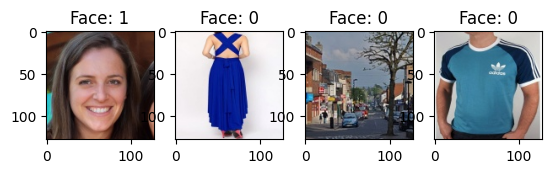

In [ ]:
# OPTIONAL check that all reads correctly
fig, ax = plt.subplots(1, 4)

i = 0
for idx in np.random.randint(0, df_labeled.shape[0], size=4, dtype=int):
    sample_image = imread(df_labeled.at[idx, "photo"])
    sample_label = df_labeled.at[idx, "face"]

    ax[i].imshow(sample_image)
    ax[i].set_title(f"Face: {sample_label}")
    i += 1
plt.show()

In [ ]:
# a cut from labeled_imgs_full.csv with ~100 of each type for model evaluation
df_labeled_test = pd.read_csv(os.path.join(img_path, "labeled_imgs_test.csv"))
df_labeled_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  200 non-null    int64 
 1   photo       200 non-null    object
 2   face        200 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 4.8+ KB


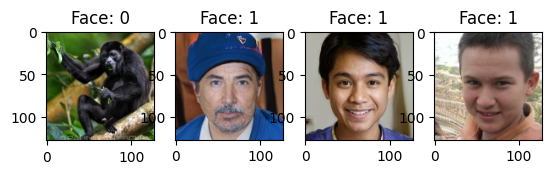

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

fig, ax = plt.subplots(1, 4)
i = 0
for idx in np.random.randint(0, df_labeled_test.shape[0], size=4, dtype=int):
    sample_image = imread(df_labeled_test.at[idx, "photo"])
    sample_label = df_labeled_test.at[idx, "face"]

    ax[i].imshow(sample_image)
    ax[i].set_title(f"Face: {sample_label}")
    i += 1
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Split the training data into target, training, and validation sets (70% train, 30% validation)
X = df_labeled["photo"]
y = df_labeled["face"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
# OPTIONAL check the split
print(f"Training set size: {len(X_train)} images")
print(f"Validation set size: {len(X_val)} images")
print("\nTraining set label distribution:")
print(y_train.value_counts(normalize=True))
print("\nValidation set label distribution:")
print(y_val.value_counts(normalize=True))

Training set size: 10500 images
Validation set size: 4501 images

Training set label distribution:
face
1    0.664952
0    0.335048
Name: proportion, dtype: float64

Validation set label distribution:
face
1    0.664963
0    0.335037
Name: proportion, dtype: float64


## 1.2 Help functions for loading and preparing images for optimal modeling
10_000 images is not a huge dataset, so I'll apply some minimalistic augmentation to the training data. But not too much so it is still possible to see just what a simple model from scratch is capable of.

In [ ]:
import tensorflow as tf

BATCH_SIZE = 32
IMG_SIZE = 64

def preprocess_image(filepath, label):
    """
    Read images from paths, decode, resize to im_size,
    normalize pixel values, and cast labels to the correct type for the model
    """
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0 # normalize images to [0, 1]
    label = tf.cast(label, tf.int32)
    return img, label

def augment_image(image, label):
    """ Apply random horizontal flip """

    image = tf.image.random_flip_left_right(image)
    return image, label


In [ ]:
# Create a tf.data.Dataset for training data
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

train_ds = train_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE) # AUTOTUNE divides in batches
train_ds = train_ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE) # minimal augmentation (should it be added instead?)
train_ds = train_ds.shuffle(buffer_size=len(X_train))
train_ds = train_ds.batch(BATCH_SIZE, drop_remainder=True) # drop_remainder=True for consistent batch sizes
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

print("Training dataset 'train_ds' is ready.")

Training dataset 'train_ds' is ready.


In [ ]:
# Same but augment and shuffle for the validation data
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))

val_ds = val_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE, drop_remainder=True)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

print("Validation dataset 'val_ds' is ready.")

Validation dataset 'val_ds' is ready.


In [ ]:
# Idem. for testing data
X_test = df_labeled_test["photo"]
y_test = df_labeled_test["face"]

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

test_ds = test_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE, drop_remainder=True)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print("Test dataset 'test_ds' is ready.")


Test dataset 'test_ds' is ready.


# Step 2: Build and train CNN from scratch

## 2.1 Building and compiling the model

After a couple of iterations causing memory crushes and running out of time, settled on this simple architecture  without extra regularization techniques (as per the task: 2–3 conv-lagen, followed by max-pooling and a dense classifier).

In [ ]:
from tensorflow.keras import layers, models, Input

# Define architecture (3 conv. layers, max-pooling, and dense classifier)
model = models.Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

print("CNN model is ready to be trained.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

CNN model is ready to be trained.


In [ ]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Path to save the model in Drive (CRUSIAL or it goes with the wind)!!!
checkpoint_filepath = os.path.join(out_path, 'best_model.keras')

model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Callback to prevent overfitting
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=7,  # Number of epochs with no improvement after which training will be stopped.
    restore_best_weights=True,
    verbose=1
)

callbacks = [model_checkpoint_callback, early_stopping_callback]

print("Callbacks are set.")

Callbacks are set.


## 2.2 Training process


In [ ]:
EPOCHS = 50

# Train the model
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

print("Model training completed.")

Epoch 1/50
210/218 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8959 - loss: 0.2194
Epoch 1: val_accuracy improved from None to 0.99093, saving model to /content/drive/Othercomputers/Mijn laptop/DS_Advanced/CNN_opdracht/output/best_model.keras

Epoch 1: finished saving model to /content/drive/Othercomputers/Mijn laptop/DS_Advanced/CNN_opdracht/output/best_model.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 1783s 2s/step - accuracy: 0.9623 - loss: 0.0923 - val_accuracy: 0.9909 - val_loss: 0.0234
Epoch 2/50
210/218 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9960 - loss: 0.0109
Epoch 2: val_accuracy did not improve from 0.99093
218/218 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.9960 - loss: 0.0117 - val_accuracy: 0.9882 - val_loss: 0.0316
Epoch 3/50
216/218 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9958 - loss: 0.0122
Epoch 3: val_accuracy did not improve from 0.99093
218/218 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.9968 - loss: 0.0089 - val_accuracy: 0.9661 - val_loss: 0.10

**Ran at T4 GPU, very slow:**
* Epoch 1 done at 21 min
* Epoch 3 at 30 min
* Epoch 7 at 32 min
* Epoch 10 at 34 min
* Epoch 15 at 35 min!

Looks good, though. Spectacular improvement after a little hickup in the beginning around epoch 3. Luckily, the model recovered and improved a lot in a couple of epochs.

Last saved version:
Epoch 10/50
212/218 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 1.9314e-04
Epoch 10: val_accuracy improved from 0.99866 to 0.99933

Continued for a while with slight overfitting (accuracy: 1.0000 - loss: 8.6251e-06 - val_accuracy: 0.9987 - val_loss: 0.0046), but early stopped at epoch 15 without overwriting the best version.

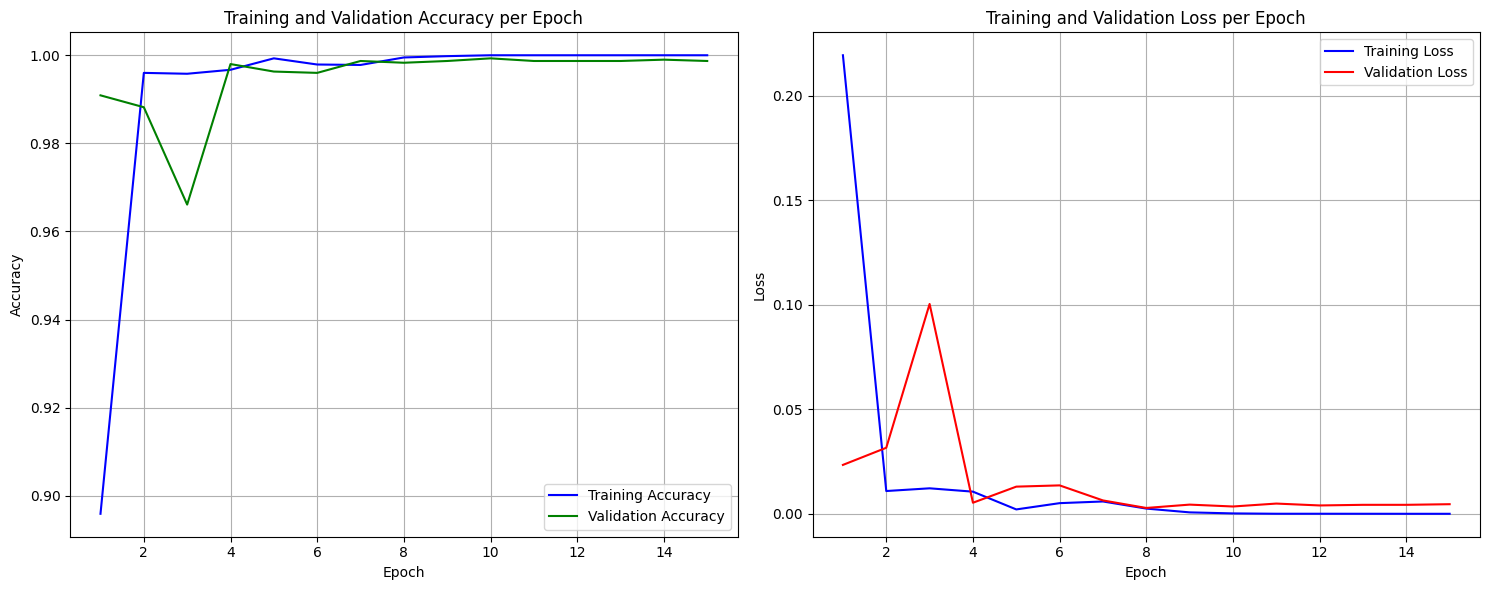

In [ ]:
import matplotlib.pyplot as plt

train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)

train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Training and Validation Accuracy
ax1.plot(epochs, train_accuracy, 'b-', label='Training Accuracy')
ax1.plot(epochs, val_accuracy, 'g-', label='Validation Accuracy')
ax1.set_title('Training and validation Accuracy per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot Training and Validation Loss
ax2.plot(epochs, train_loss, 'b-', label='Training Loss')
ax2.plot(epochs, val_loss, 'r-', label='Validation Loss')
ax2.set_title('Training and Validation Loss per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

As the plots confirm, we've got a fast learner with its peak performance by the 10th epoch. Luckily, this time I had it saved. :)

## 2.3 Evaluating the best saved model on the new (unseen) data
(Test set is completely separate but images are similar to the train/val data)


In [ ]:
import os
from tensorflow.keras.models import load_model

# Load the best saved model
saved_model = os.path.join(out_path, 'best_model.keras')
best_cnn = load_model(saved_model)

print("Model loaded successfully!")
best_cnn.summary()

Model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049,989 (7.82 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,366,660 (5.21 MB)

In [ ]:
loss, accuracy = best_cnn.evaluate(test_ds)

print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 40s 6s/step - accuracy: 1.0000 - loss: 4.1111e-06
Final Validation Loss: 0.0000
Final Validation Accuracy: 1.0000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


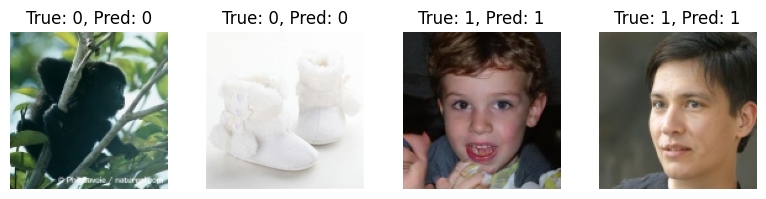

In [ ]:
# visualizing predictions
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
import tensorflow as tf

# Function to preprocess a single image for prediction (similar to preprocess_image but returns only image)
def preprocess_single_image(filepath):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img

# Select a few random indices from the test set
num_samples_to_show = 4
random_indices = np.random.choice(len(X_test), num_samples_to_show, replace=False)

# Prepare images and labels for display and prediction
sample_images_for_pred = []
sample_true_labels = []
display_images = []

for idx in random_indices:
    filepath = X_test.iloc[idx]
    true_label = y_test.iloc[idx]

    processed_img = preprocess_single_image(filepath)
    sample_images_for_pred.append(processed_img)
    display_images.append(imread(filepath))
    sample_true_labels.append(true_label)

# Convert to a batch and make predictions
predictions_input = tf.stack(sample_images_for_pred)
predictions = best_cnn.predict(predictions_input)
predicted_labels = (predictions > 0.5).astype(int).flatten()

# Display results
fig, axes = plt.subplots(1, num_samples_to_show, figsize=(8, 2))

for i, ax in enumerate(axes):
    ax.imshow(display_images[i])
    ax.set_title(f"True: {sample_true_labels[i]}, Pred: {predicted_labels[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

This looks quite promising and ready to proceed to the real test of goodness.

# Step 3: Faces detection with the sliding window approach

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage.io import imread

import tensorflow as tf
from tensorflow.keras.models import load_model

# Load the model
saved_model = os.path.join(out_path, 'best_model.keras')
best_cnn = load_model(saved_model)
print("Model loaded successfully!")

BATCH_SIZE = 32
IMG_SIZE = 64


Model loaded successfully!


## 3.1 Functions to implement sliding window algorithm

In [4]:
# function to cut out sliding windows one by one
def sliding_window(image, window_size, step_size):
    """
    Yields a window and its top-left coordinates from an image.
    """
    image_height, image_width = image.shape[:2]

    # Ensure window_size does not exceed image dimensions, and image has enough pixels
    if window_size > image_height or window_size > image_width or image_height < window_size or image_width < window_size:
        return # Skip if window is larger than image or image is too small

    for y in range(0, image_height - window_size + 1, step_size):
        for x in range(0, image_width - window_size + 1, step_size):
            # Extract each window with its coordinates
            window = image[y : y + window_size, x : x + window_size]
            yield (window, (x, y))

# function to preprocess the extracted image window (kuddos to Gemini)
def preprocess_window_for_prediction(window_array, target_size=IMG_SIZE):
    """
    Resizes the window to target_size x target_size.
    """
    # Ensure window is RGB (in case it's grayscale)
    if len(window_array.shape) == 2:
        window_array = np.stack([window_array]*3, axis=-1)

    # Convert numpy array to TensorFlow tensor
    img_tensor = tf.convert_to_tensor(window_array, dtype=tf.float32)
    # Resize the window to the model's expected input size (IMG_SIZE)
    img_tensor = tf.image.resize(img_tensor, [target_size, target_size])
    img_tensor = img_tensor / 255.0
    return img_tensor


## 3.2 Use the model to make prediction for each window


In [5]:
def detect_faces(test_image, window_sizes, step_ratio=0.125, confidence_threshold=0.97):
    """
    Outputs a list of bounding boxes
    along with the size, coordinates, and confidence score
    """
    detected_faces = []

    for wins in window_sizes:
        print(f"Sliding over with window {wins} by {wins}")
        step_size = int(wins * step_ratio)
        if step_size == 0: step_size = 1 # Avoid infinite loops for very small step_ratio

        # Batching for speeding up
        # TODO: limit BATCH_SIZE for memory efficiency
        current_batch_windows = []
        current_batch_coords = []

        # Collect windows and coordinates for the current window_size
        for window, (x, y) in sliding_window(test_image, wins, step_size):
            processed_window = preprocess_window_for_prediction(window, target_size=IMG_SIZE)
            current_batch_windows.append(processed_window)
            current_batch_coords.append((x, y))

        hits = 0
        if current_batch_windows:
            # Convert to a single TensorFlow batch
            batch_to_predict = tf.stack(current_batch_windows)

            # Perform prediction on the entire batch
            predictions = best_cnn.predict(batch_to_predict)
            confidence_scores = predictions.flatten()

            # Iterate through predictions and their corresponding original coordinates
            for i, score in enumerate(confidence_scores):
                if score > confidence_threshold:
                    hits += 1
                    x, y = current_batch_coords[i]
                    detected_faces.append((x, y, wins, wins, score))
        print(f"{hits} hit(s)")

    print(f"Detected {len(detected_faces)} faces with confidence > {confidence_threshold}.")
    return detected_faces

# Step 4: Visualize Detections

## 4.1 Put it in a function for re-use

In [6]:
def visualize_detections(test_image, detected_faces, annot=False):

  plt.imshow(test_image)

  # Iterate through the detected_faces list and draw bounding boxes
  for (x, y, w, h, confidence) in detected_faces:
      # Create a Rectangle patch and add to the axes
      rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='#33ee00', facecolor='none')
      plt.gca().add_patch(rect)

      if annot:
        # Add confidence score as annotation
        plt.text(x, y - 5, f'Conf: {confidence:.2f}', bbox=dict(facecolor='green', alpha=0.5), fontsize=8, color='white')
      plt.axis('off');

 ## 4.2 The moment of truth -- how good is the model in detecting faces on photos?

In [7]:
photos_path = os.path.join(img_path, "photos/")
photos = {}
for p in os.listdir(photos_path):
    photos[p[:-4]] = os.path.join(photos_path, p)

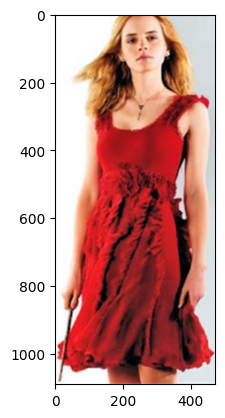

In [ ]:
test_image = imread(photos["hermione"]) # 1 face
plt.imshow(test_image);

Sliding over with window 64 by 64
2 hit(s)
Sliding over with window 128 by 128
0 hit(s)
Sliding over with window 184 by 184
1 hit(s)
Sliding over with window 256 by 256
0 hit(s)
Detected 3 faces with confidence > 0.97.


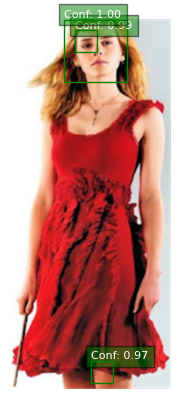

In [ ]:
detected_faces = detect_faces(test_image, window_sizes=[64, 128, 184, 256])
visualize_detections(test_image, detected_faces, annot=True)

So now, with the right window size (or increasing confidence_threshold to 1.00) we should get the perfect match.

Sliding over with window 184 by 184
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
1 hit(s)
Detected 1 faces with confidence > 0.97.


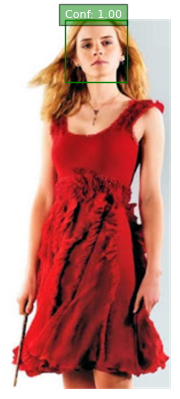

In [ ]:
detected_faces = detect_faces(test_image, window_sizes=[184])
visualize_detections(test_image, detected_faces, annot=True)

Yaay!

Sliding over with window 64 by 64
Sliding over with window 128 by 128
Sliding over with window 256 by 256
Detected 5 faces with confidence > 0.95 across all window sizes.


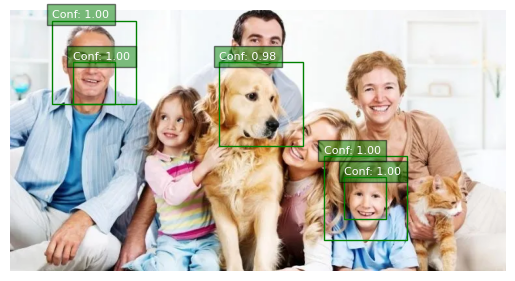

In [ ]:
test_image = imread(photos["fake_family"]) # 6 faces
detected_faces = detect_faces(test_image, window_sizes=[64, 128, 256], confidence_threshold=0.95)
visualize_detections(test_image, detected_faces, annot=True)

Hmm, my model seems to favor pets over females...

Sliding over with window 100 by 100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
2 hit(s)
Sliding over with window 128 by 128
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1 hit(s)
Detected 3 faces with confidence > 0.98.


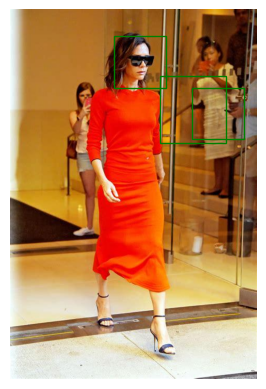

In [ ]:
test_image = imread(photos["victoria"]) # 3 faces maximum
detected_faces = detect_faces(test_image, window_sizes=[100, 128], step_ratio=0.25, confidence_threshold=0.98)
visualize_detections(test_image, detected_faces)

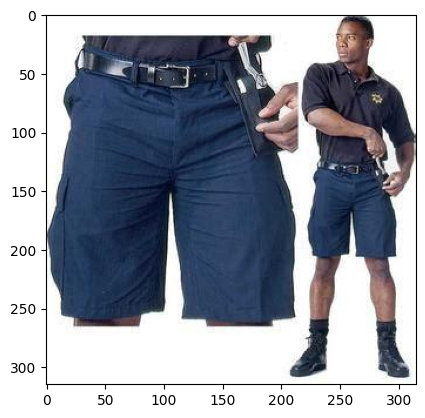

In [ ]:
test_image = imread(photos["agent"]) # 1 face
plt.imshow(test_image);

In [ ]:
detected_faces = detect_faces(test_image, window_sizes=[48, 64], confidence_threshold=0.95)
if detected_faces:
    visualize_detections(test_image, detected_faces)
else:
    print("No faces detected :(")

Sliding over with window 48 by 48
0 hit(s)
Sliding over with window 64 by 64
0 hit(s)
Detected 0 faces with confidence > 0.95.
No faces detected :(


Oops, did I create a racist model? <O.O>

Sliding over with window 32 by 32
Sliding over with window 64 by 64
Sliding over with window 128 by 128
Sliding over with window 256 by 256
Detected 2 faces with confidence > 0.98 across all window sizes.


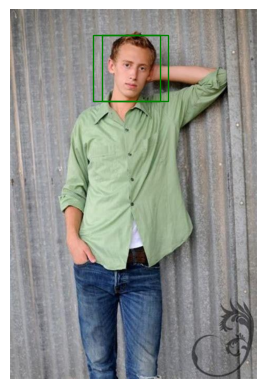

In [ ]:
test_image = imread(photos["guy"]) # 1 face
detected_faces = detect_faces(test_image, window_sizes=[32, 64, 128, 256], confidence_threshold=0.98)
visualize_detections(test_image, detected_faces)

So far, my model seems to be the best in detecting white males.

Sliding over with window 64 by 64
1 hits
Sliding over with window 128 by 128
6 hits
Sliding over with window 256 by 256
5 hits
Detected 12 faces with confidence > 0.98.


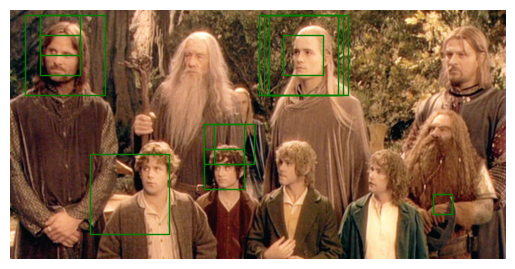

In [ ]:
test_image = imread(photos["lotr"]) # 9 faces
detected_faces = detect_faces(test_image, window_sizes=[64, 128, 256], confidence_threshold=0.98)
visualize_detections(test_image, detected_faces)

Correction: only handsome white males. :)))

Sliding over with window 64 by 64
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
0 hit(s)
Sliding over with window 128 by 128
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
1 hit(s)
Detected 1 faces with confidence > 0.99.


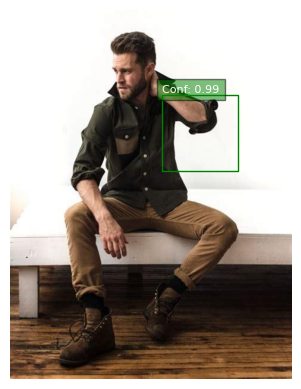

In [ ]:
test_image = imread(photos["man"]) # 1 face
detected_faces = detect_faces(test_image, window_sizes=[64,128], confidence_threshold=0.99)
visualize_detections(test_image, detected_faces, annot=True)

Apparently it is not recognizing faces at an angle.

Sliding over with window 112 by 112
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5 hit(s)
Sliding over with window 128 by 128
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
3 hit(s)
Detected 8 faces with confidence > 0.99.


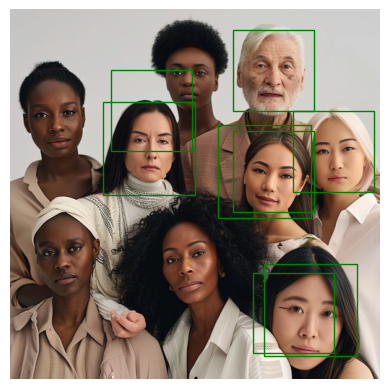

In [ ]:
test_image = imread(photos["fakeppl9"]) # 9 faces
detected_faces = detect_faces(test_image, window_sizes=[112, 128], step_ratio=0.25, confidence_threshold=0.99)
visualize_detections(test_image, detected_faces)

Ouch. Not good.

Sliding over with window 100 by 100
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step
14 hit(s)
Sliding over with window 112 by 112
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step
14 hit(s)
Sliding over with window 128 by 128
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
14 hit(s)
Detected 42 faces with confidence > 0.97.


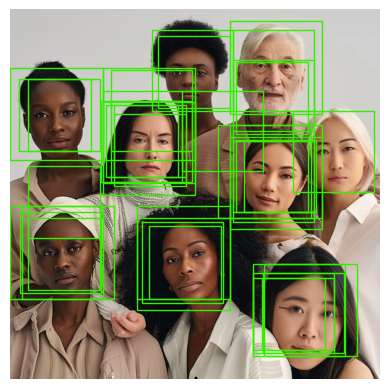

In [ ]:
detected_faces = detect_faces(test_image, window_sizes=[100, 112, 128]) # decreased step_ratio and confidence_threshold by using the defaults
visualize_detections(test_image, detected_faces)

This is much better: all faces are detected. Only now there are too many same ones. It is time to move to the next step: apply NMS for removing overlapping boxes.

In [9]:
def apply_nms(all_detections, iou_threshold=0.5, confidence_threshold=0.97):
    """
    Applies Non-Maximum Suppression to filter overlapping bounding boxes.

    Args:
        raw_detections: A list of tuples (x, y, w, h, confidence) from detect_faces.
        iou_threshold: Intersection Over Union threshold for NMS (default 50% overlap).
        confidence_threshold: Minimum confidence score to consider for NMS.

    Returns:
        A list of filtered bounding boxes with their scores after NMS.
    """
    if not all_detections:
        return []

    # Separate boxes and scores
    boxes = [(d[0], d[1], d[2], d[3]) for d in all_detections]
    scores = [d[4] for d in all_detections]

    # Convert to TensorFlow tensors. NMS expects [y1, x1, y2, x2]
    tf_boxes = tf.constant([[box[1], box[0], box[1] + box[3], box[0] + box[2]] for box in boxes], dtype=tf.float32)
    tf_scores = tf.constant(scores, dtype=tf.float32)

    # Apply NMS
    selected_indices = tf.image.non_max_suppression(
        boxes=tf_boxes,
        scores=tf_scores,
        max_output_size=len(boxes), # Keep all possible detections for now
        iou_threshold=iou_threshold,
        score_threshold=confidence_threshold
    )

    # Filter and return the selected boxes
    final_detections = []
    for i in selected_indices.numpy():
        original_box = boxes[i]
        original_score = scores[i]
        final_detections.append((original_box[0], original_box[1], original_box[2], original_box[3], original_score))

    print(f"{len(final_detections)} face(s) remained after NMS-filtering.")
    return final_detections

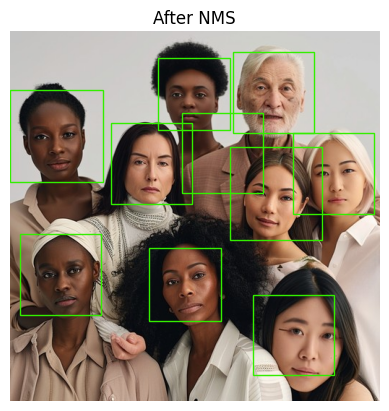

In [ ]:
final_faces = apply_nms(detected_faces, iou_threshold=0.15)
visualize_detections(test_image, final_faces)
plt.title("After NMS")
plt.show()

Looks good, so trying it on a different photo.

Sliding over with window 80 by 80
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step
9 hit(s)
Sliding over with window 128 by 128
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
2 hit(s)
Detected 11 faces with confidence > 0.97.


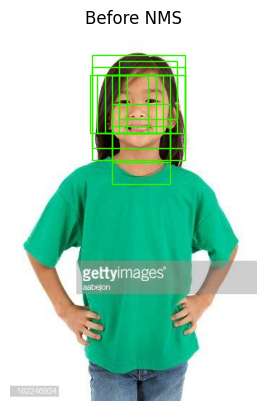

1 face(s) remained after NMS-filtering.


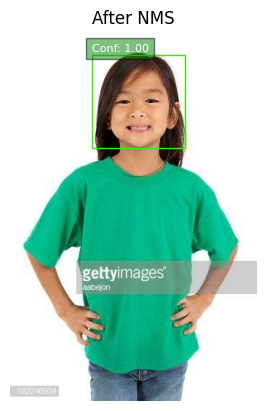

In [ ]:
test_image = imread(photos["girl"]) # 1 face
all_faces = detect_faces(test_image, window_sizes=[80, 128])
visualize_detections(test_image, all_faces)
plt.title("Before NMS")
plt.show()
final_faces = apply_nms(all_faces, iou_threshold=0.1)
visualize_detections(test_image, final_faces, annot=True)
plt.title("After NMS")
plt.show()

Awesome! But is the model good enough when faced with a real challenge: a crowd?

Sliding over with window 42 by 42
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step
11 hit(s)
Sliding over with window 56 by 56
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step
8 hit(s)
Sliding over with window 64 by 64
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step
24 hit(s)
Detected 43 faces with confidence > 0.99.


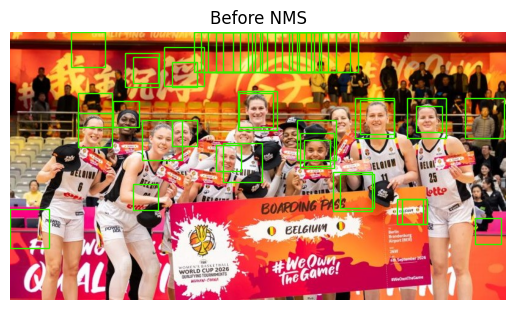

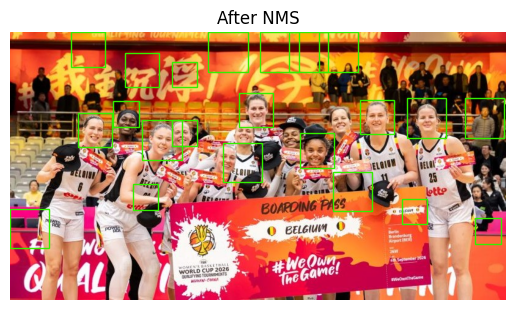

In [ ]:
test_image = imread(photos["basket"]) # many faces
all_faces = detect_faces(test_image, window_sizes=[42, 56, 64], step_ratio=0.2, confidence_threshold=0.99)
visualize_detections(test_image, all_faces)
plt.title("Before NMS")
plt.show()
final_faces = apply_nms(all_faces, iou_threshold=0.2)
visualize_detections(test_image, final_faces)
plt.title("After NMS")
plt.show()

What about mixed intergalactic races?..

Sliding over with window 90 by 90
158/158 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step
27 hit(s)
Sliding over with window 112 by 112
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step
23 hit(s)
Sliding over with window 128 by 128
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step
12 hit(s)
Sliding over with window 148 by 148
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step
6 hit(s)
Detected 68 faces with confidence > 0.97.


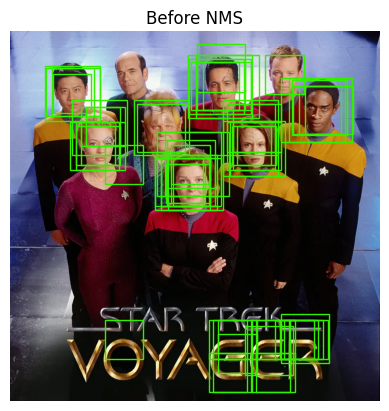

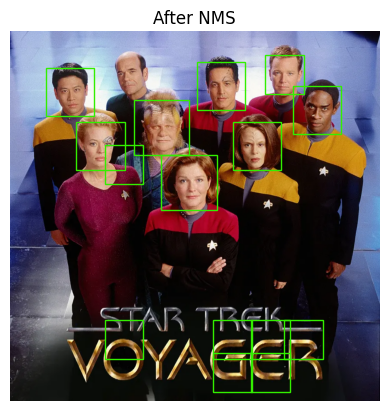

In [ ]:
test_image = imread(photos["voyager"])
all_faces = detect_faces(test_image, window_sizes=[90, 112, 128, 148])
visualize_detections(test_image, all_faces)
plt.title("Before NMS")
plt.show()
final_faces = apply_nms(all_faces, iou_threshold=0.3)
visualize_detections(test_image, final_faces)
plt.title("After NMS")
plt.show()

Correct! All humans, aliens, and even a borg got detected. The only one not identified as a face is the Doctor, which makes perfect sense because he is a hologram. :)

**LIVE DEMO**

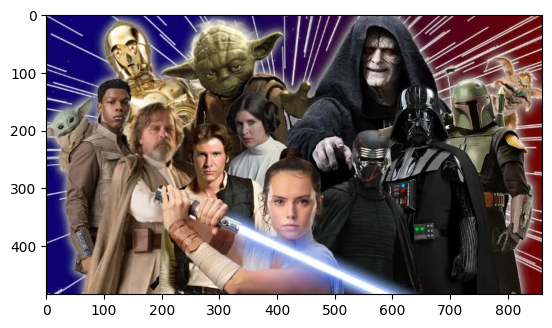

In [ ]:
test_image = imread(photos["starwars"]) # ? faces
plt.imshow(test_image);

Sliding over with window 64 by 64
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
10 hit(s)
Sliding over with window 90 by 90
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
6 hit(s)
Sliding over with window 112 by 112
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
1 hit(s)
Sliding over with window 128 by 128
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2 hit(s)
Sliding over with window 142 by 142
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2 hit(s)
Detected 21 faces with confidence > 0.92.


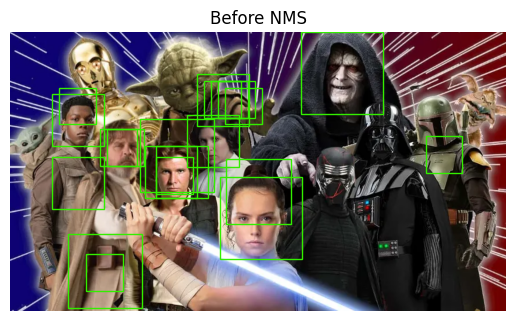

9 face(s) remained after NMS-filtering.


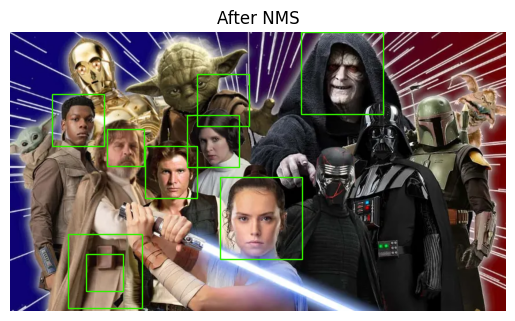

In [ ]:
all_faces = detect_faces(test_image, window_sizes=[64, 90, 112, 128, 142], step_ratio=0.2, confidence_threshold=0.92)
visualize_detections(test_image, all_faces)
plt.title("Before NMS")
plt.show()
final_faces = apply_nms(all_faces, iou_threshold=0.3)
visualize_detections(test_image, final_faces)
plt.title("After NMS")
plt.show()

What about masks?

Sliding over with window 48 by 48
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
20 hit(s)
Sliding over with window 56 by 56
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
8 hit(s)
Sliding over with window 90 by 90
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4 hit(s)
Detected 32 faces with confidence > 0.98.


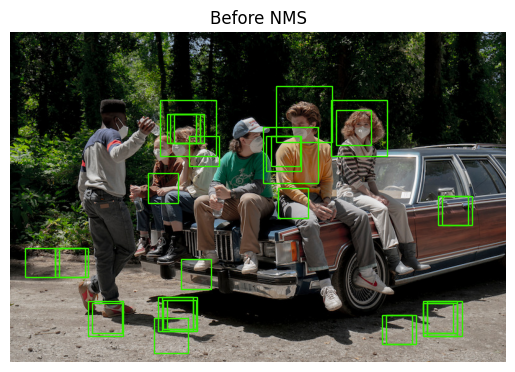

16 face(s) remained after NMS-filtering.


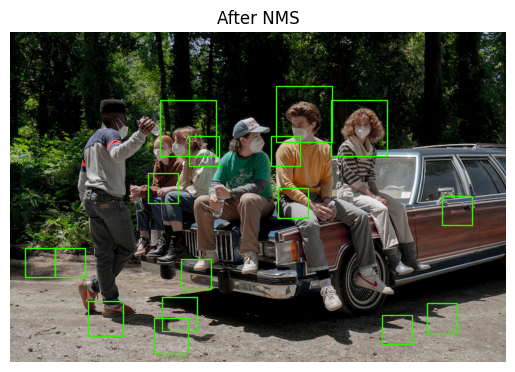

In [ ]:
test_image = imread(photos["strangerthings"])
all_faces = detect_faces(test_image, window_sizes=[48, 56, 90], confidence_threshold=0.98)
visualize_detections(test_image, all_faces)
plt.title("Before NMS")
plt.show()
final_faces = apply_nms(all_faces, iou_threshold=0.2)
visualize_detections(test_image, final_faces)
plt.title("After NMS")
plt.show()

# Takeaways and insights:
- Despite its pretty basic configuration, my CNN model performed quite well in detecting faces.
- It is not great in identifying (non-)faces though, and often hallucinates faces where there are none. This could be improved with one of the following (ordered ascending by effort and effect):
  - adding augmentation functions to diversify the current dataset;
  - adding more diversified training images (both faces and non-faces);
  - using a pre-trained model via transfer learning.

Changing the architecture and/or parameters of the model itself would most likely be less effective than the quantity and versatility of the training data.
- Takeaways with respect to the data:
    - The non-faces images should be scaled the same way as faces images (which was not the case here). Also I should have included parts of the interior (but did not think about).
    - The test images should be different from the training/validation (in this case they were similar). Here again, a larger and more diverse test set might have been better in showing the model shortcomings and week spots (like faces at an angle, very narrow faces, etc).
    - A clear definition of what is/isn't a face is also very important (e.g. rotation angle, masks or face-garments, portraits, fantasy characters/creatures, etc.)
- Sliding window detection results vary strongly in function of several factors, such as:
    - size(s) of the window and the stride (step_ratio) with respect to the faces on the picture;
    - confidence threshold;
    - iou threshold for the nms filtering;
    - and of course the quality of the picture itself (e.g. blurred, too dark, etc.).